# Decision Trees

### 1-Kütüphaneleri import edelim

In [38]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from warnings import filterwarnings
filterwarnings("ignore")

### 2-Dataset'leri alalım

In [39]:
train_data=pd.read_csv(r"data/train.csv")
test_data=pd.read_csv(r"data/test.csv")

### 3- Exploratory Data Analysis (EDA)

In [40]:
train_data.head()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [41]:
all_data=pd.concat((train_data.loc[:,"Gender":"satisfaction"],
                    test_data.loc[:,"Gender":"satisfaction"]))

In [42]:
all_data.isnull().sum()

Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Inflight wifi service                  0
Departure/Arrival time convenient      0
Ease of Online booking                 0
Gate location                          0
Food and drink                         0
Online boarding                        0
Seat comfort                           0
Inflight entertainment                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Inflight service                       0
Cleanliness                            0
Departure Delay in Minutes             0
Arrival Delay in Minutes             393
satisfaction                           0
dtype: int64

In [43]:
print("%",all_data["Arrival Delay in Minutes"].isnull().sum()/all_data.shape[0]*100)

% 0.3025870033877425


In [44]:
all_data["Arrival Delay in Minutes"].head()

0    18.0
1     6.0
2     0.0
3     9.0
4     0.0
Name: Arrival Delay in Minutes, dtype: float64

In [45]:
all_data["Arrival Delay in Minutes"].describe()

count    129487.000000
mean         15.091129
std          38.465650
min           0.000000
25%           0.000000
50%           0.000000
75%          13.000000
max        1584.000000
Name: Arrival Delay in Minutes, dtype: float64

<Axes: ylabel='Arrival Delay in Minutes'>

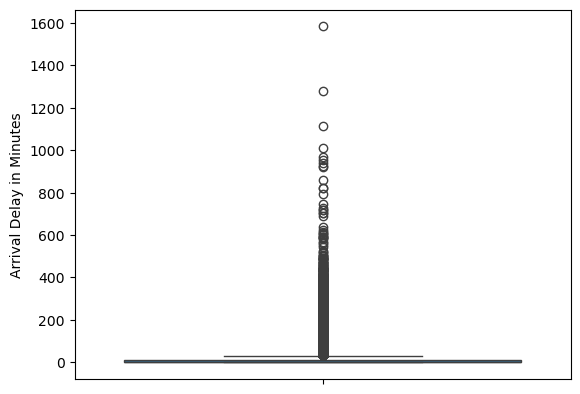

In [46]:
sns.boxplot(all_data["Arrival Delay in Minutes"])

In [47]:
all_data["Arrival Delay in Minutes"]=all_data["Arrival Delay in Minutes"].fillna(all_data["Arrival Delay in Minutes"].median())

In [48]:
all_data["Arrival Delay in Minutes"].describe()

count    129880.000000
mean         15.045465
std          38.416353
min           0.000000
25%           0.000000
50%           0.000000
75%          13.000000
max        1584.000000
Name: Arrival Delay in Minutes, dtype: float64

In [49]:
all_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 129880 entries, 0 to 25975
Data columns (total 23 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Gender                             129880 non-null  object 
 1   Customer Type                      129880 non-null  object 
 2   Age                                129880 non-null  int64  
 3   Type of Travel                     129880 non-null  object 
 4   Class                              129880 non-null  object 
 5   Flight Distance                    129880 non-null  int64  
 6   Inflight wifi service              129880 non-null  int64  
 7   Departure/Arrival time convenient  129880 non-null  int64  
 8   Ease of Online booking             129880 non-null  int64  
 9   Gate location                      129880 non-null  int64  
 10  Food and drink                     129880 non-null  int64  
 11  Online boarding                    129880 non

In [50]:
all_data.isnull().sum()

Gender                               0
Customer Type                        0
Age                                  0
Type of Travel                       0
Class                                0
Flight Distance                      0
Inflight wifi service                0
Departure/Arrival time convenient    0
Ease of Online booking               0
Gate location                        0
Food and drink                       0
Online boarding                      0
Seat comfort                         0
Inflight entertainment               0
On-board service                     0
Leg room service                     0
Baggage handling                     0
Checkin service                      0
Inflight service                     0
Cleanliness                          0
Departure Delay in Minutes           0
Arrival Delay in Minutes             0
satisfaction                         0
dtype: int64

### Numerik değişkenler

In [51]:
numeric_cols=all_data.select_dtypes(include=["int64","float64"]).columns
numeric_cols

Index(['Age', 'Flight Distance', 'Inflight wifi service',
       'Departure/Arrival time convenient', 'Ease of Online booking',
       'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
       'Inflight entertainment', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Inflight service',
       'Cleanliness', 'Departure Delay in Minutes',
       'Arrival Delay in Minutes'],
      dtype='object')

### Kategorik değişkenler

In [52]:
categoric_cols=all_data.select_dtypes(include="object").columns
categoric_cols

Index(['Gender', 'Customer Type', 'Type of Travel', 'Class', 'satisfaction'], dtype='object')

## 4-Görselleştirme

(0.0, 90.0)

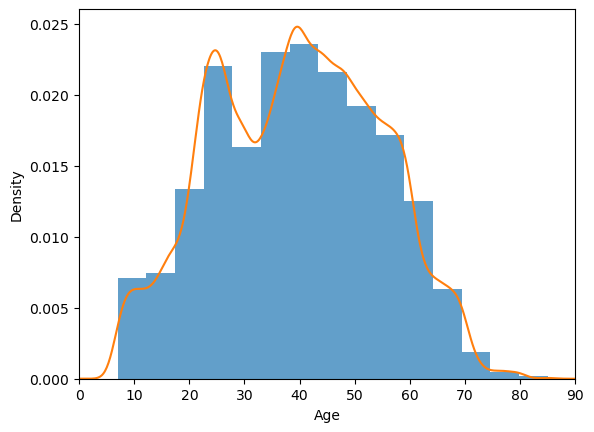

In [53]:
ax=all_data["Age"].hist(bins=15,density=True,stacked=True,alpha=0.7)
all_data["Age"].plot(kind="density")
ax.set(xlabel="Age")
plt.xlim(0,90)

In [54]:
all_data["satisfaction"]

0        neutral or dissatisfied
1        neutral or dissatisfied
2                      satisfied
3        neutral or dissatisfied
4                      satisfied
                  ...           
25971    neutral or dissatisfied
25972                  satisfied
25973    neutral or dissatisfied
25974                  satisfied
25975    neutral or dissatisfied
Name: satisfaction, Length: 129880, dtype: object

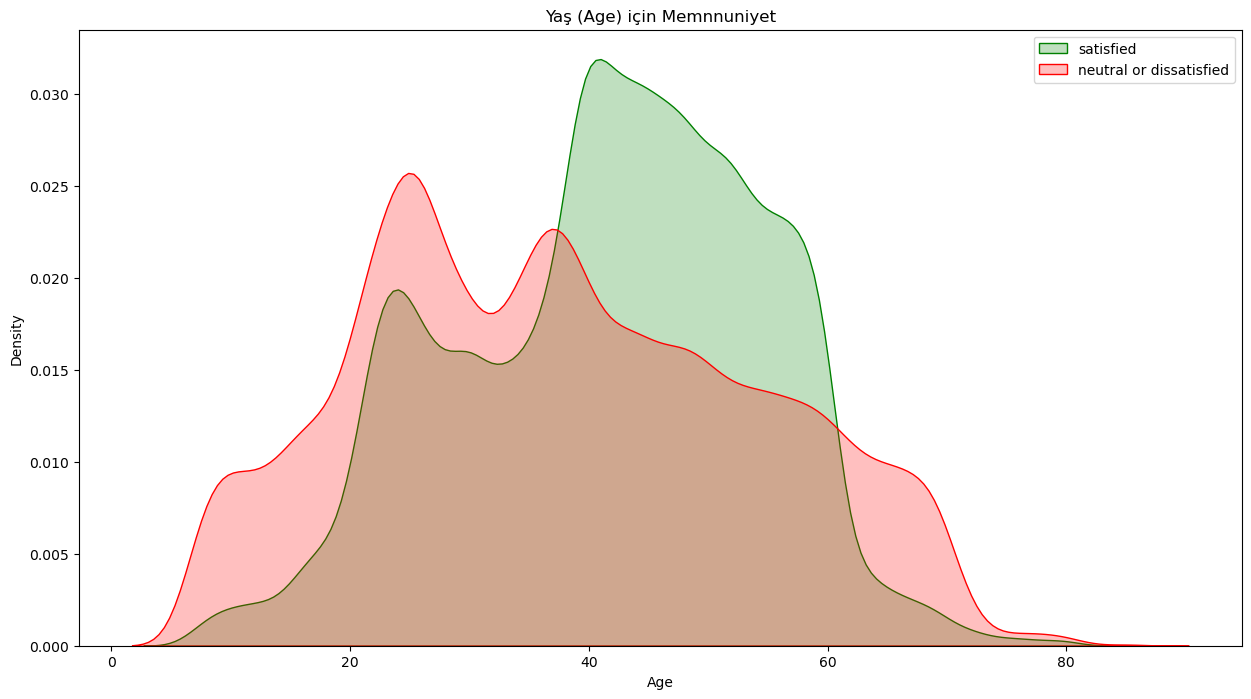

In [55]:
plt.figure(figsize=(15,8))
ax=sns.kdeplot(all_data["Age"][all_data.satisfaction=="satisfied"],color="green",shade=True)
sns.kdeplot(all_data["Age"][all_data.satisfaction=="neutral or dissatisfied"],color="red",shade=True)

plt.legend(["satisfied","neutral or dissatisfied"])
plt.title("Yaş (Age) için Memnnuniyet")
#plt.xlim(-10,85)
plt.show()

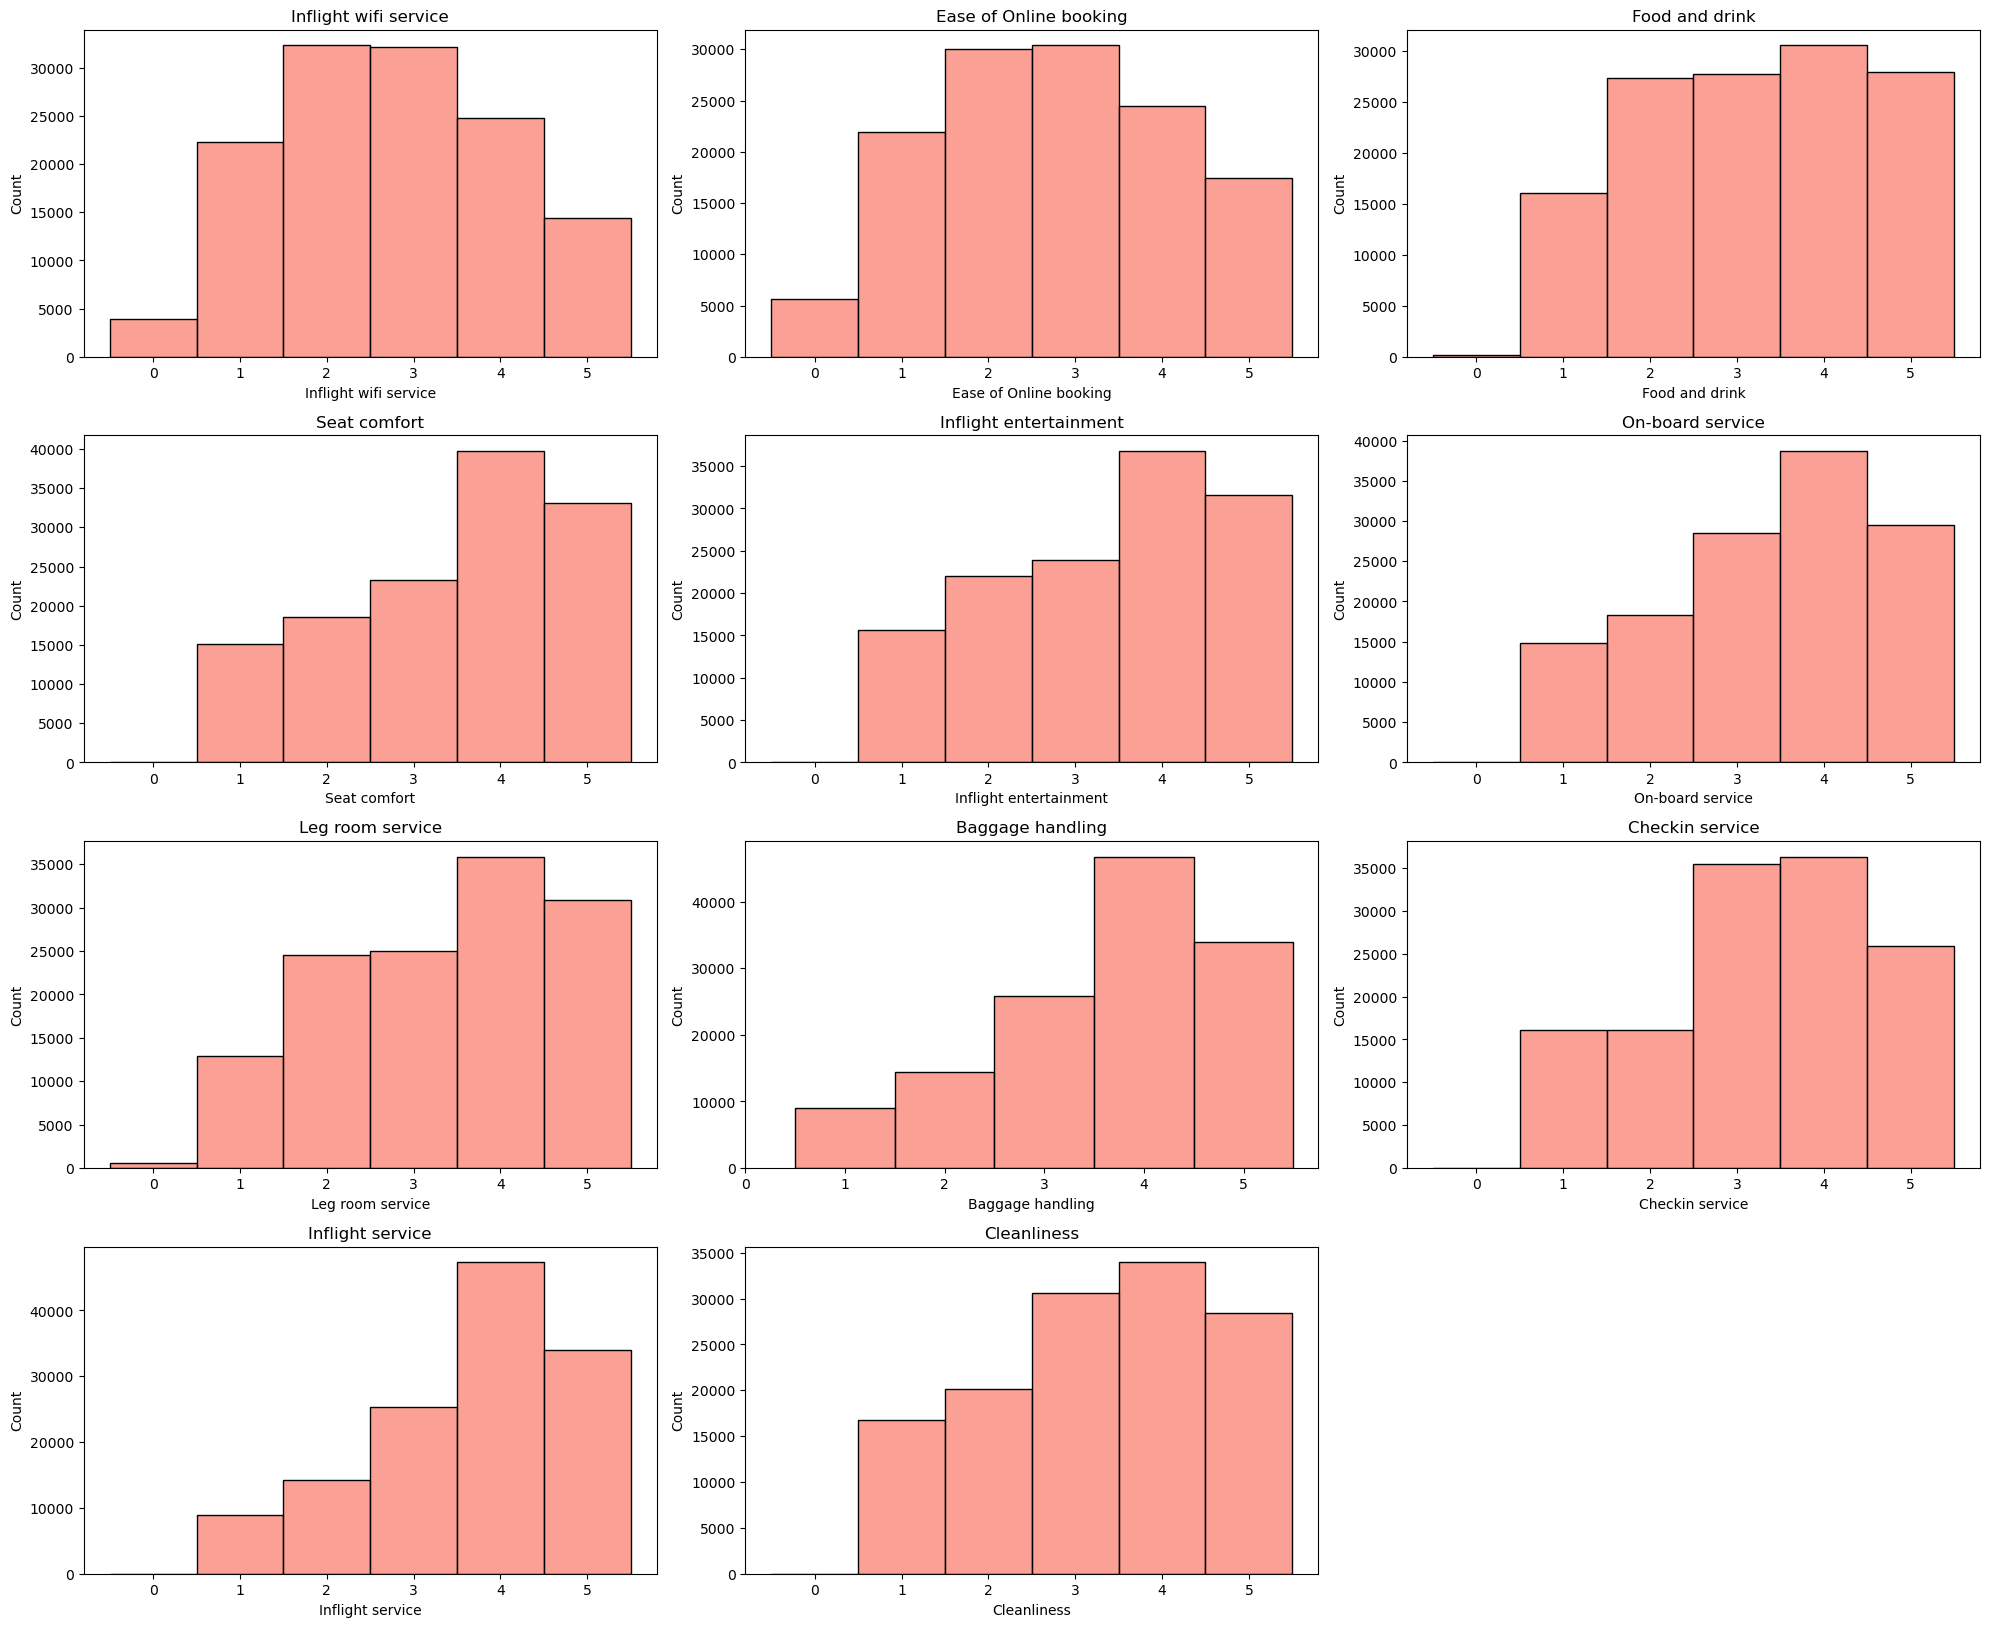

In [56]:
# Anket sütunlarını filtreleyelim (Genelde 1-5 arası puan içerenler)
survey_cols = [col for col in all_data.columns if 'service' in col.lower() or 'Ease' in col or 'Food' in col or 'Seat' in col or 'Inflight' in col or 'Cleanliness' in col or 'Leg' in col or 'Baggage' in col or 'Checkin' in col]

# Çok fazla sütun olduğu için alt alta/yan yana bir düzen kuralım
plt.figure(figsize=(20, 20))

for i, col in enumerate(survey_cols, 1):
    plt.subplot(5, 3, i) # 5 satır 3 sütunluk bir matris
    sns.histplot(all_data[col], bins=6, color='Salmon', discrete=True)
    plt.title(col)
    plt.xticks(range(6)) # 0'dan 5'e kadar puanlar

plt.tight_layout()
plt.show()

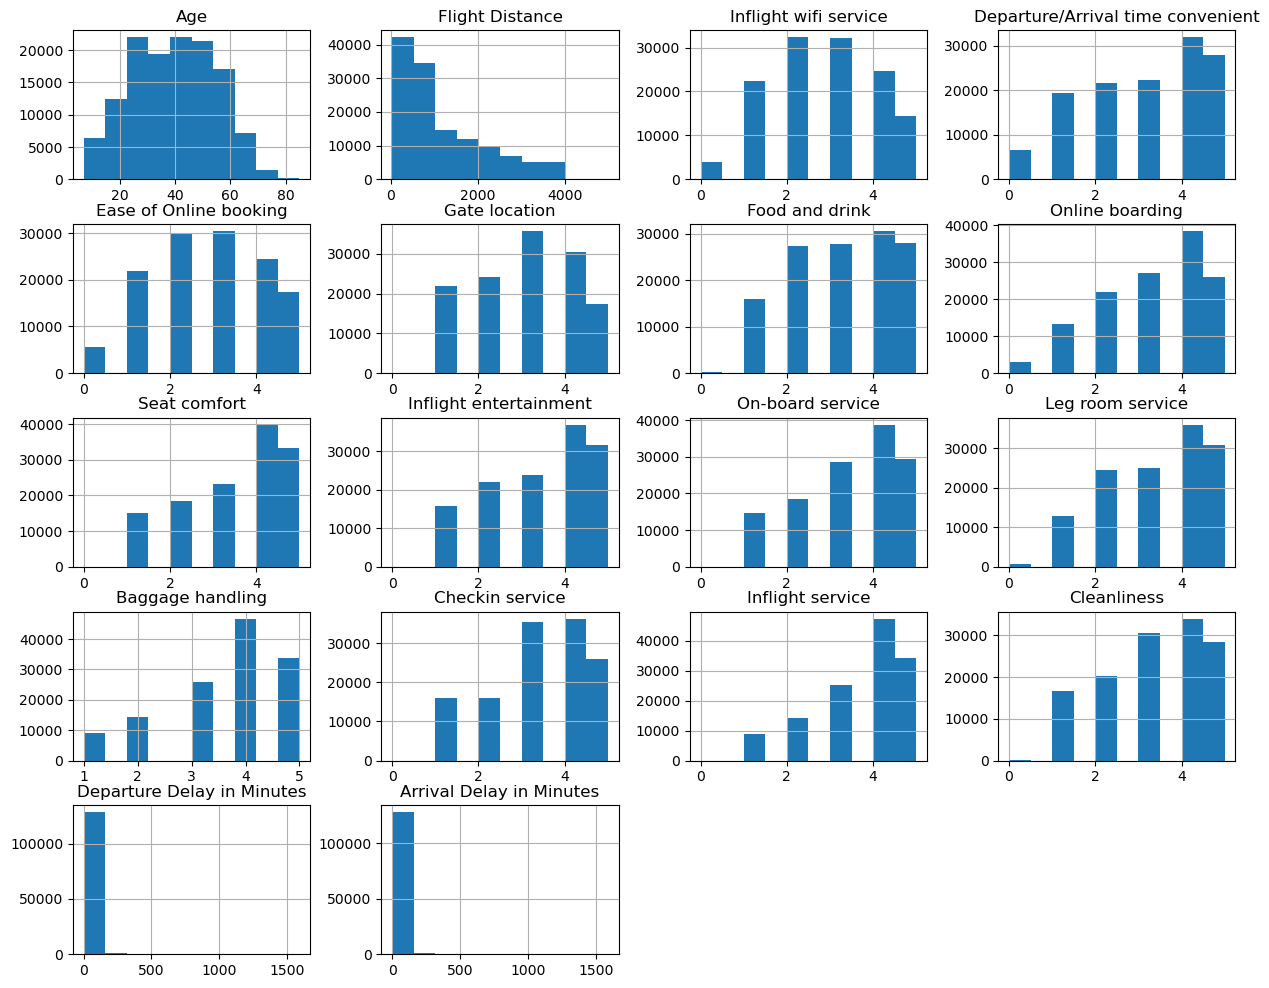

In [57]:
all_data.hist(column=numeric_cols,figsize=(15,12))
plt.show()

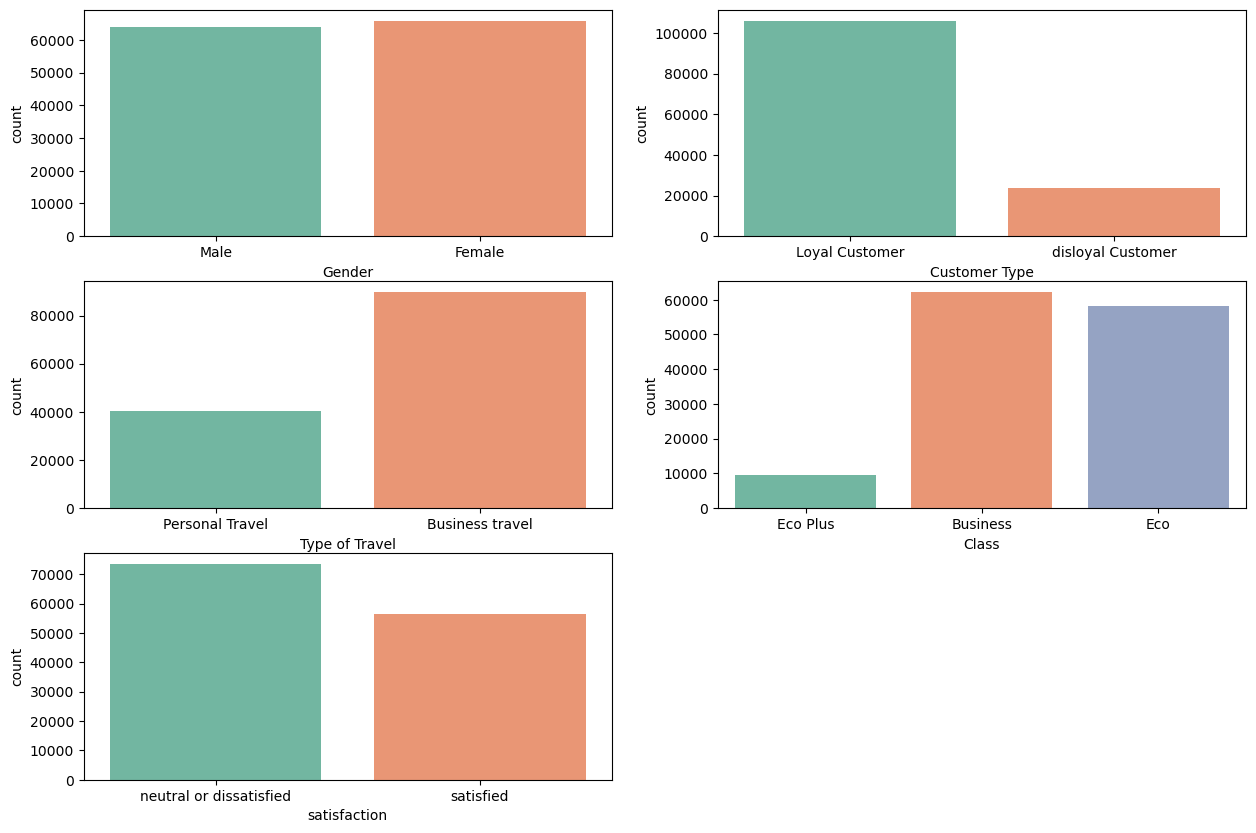

In [58]:
fig=plt.figure(figsize=(15,10))
for i in range(len(categoric_cols)):
    plt.subplot(3,2,i+1)
    sns.countplot(x=all_data[categoric_cols[i]],palette="Set2",data=all_data)

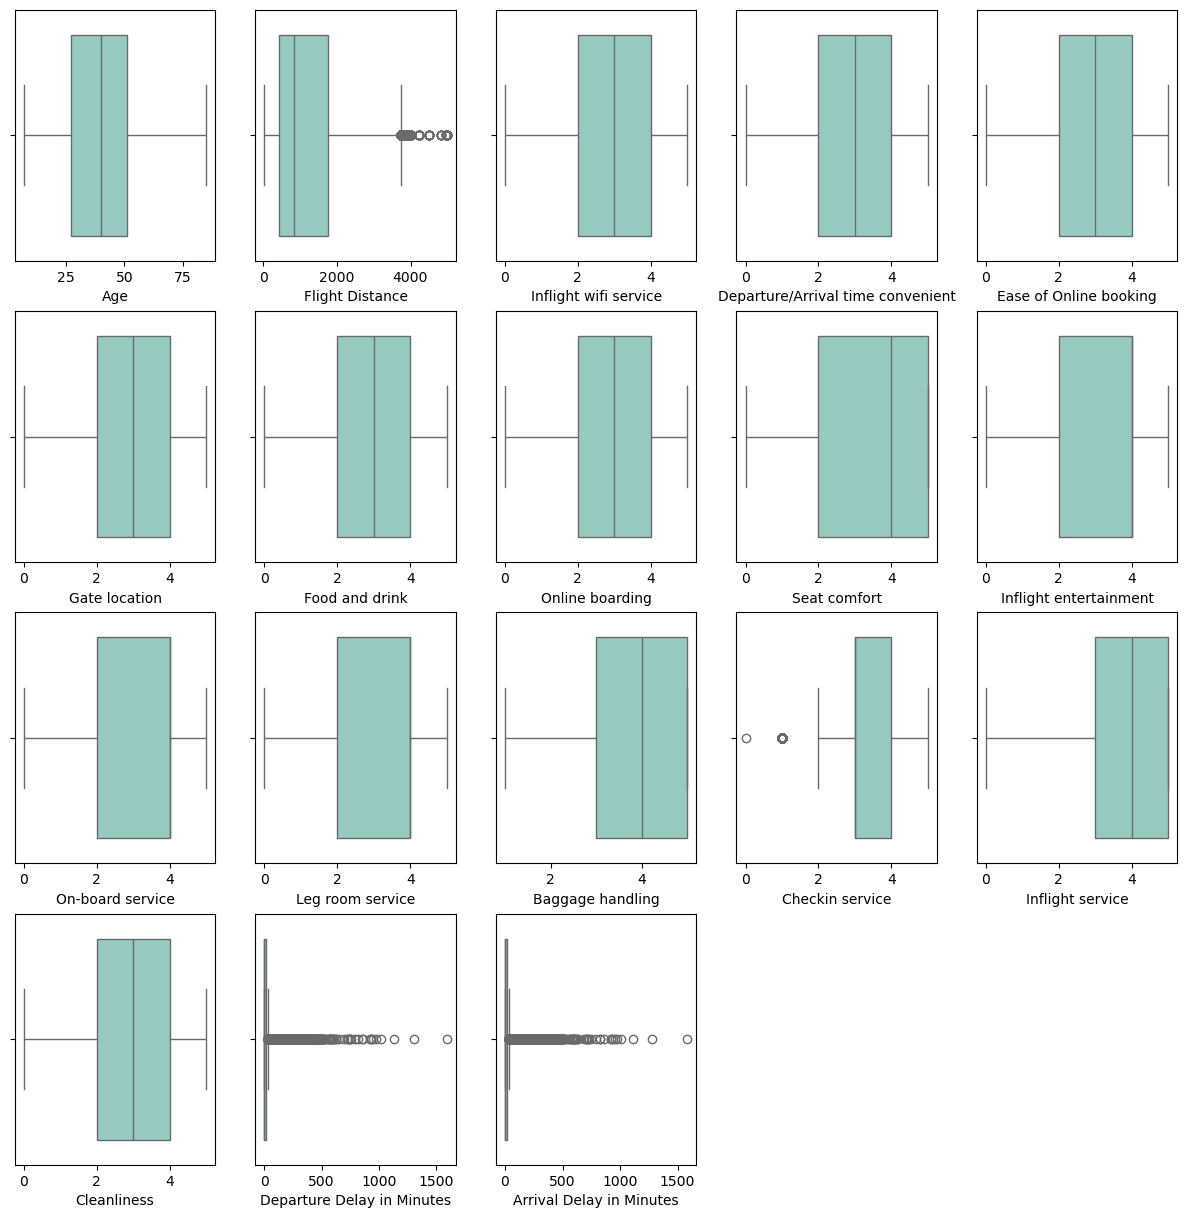

In [59]:
fig=plt.figure(figsize=(15,15))
for i in range(len(numeric_cols)):
    plt.subplot(4,5,i+1)
    sns.boxplot(x=all_data[numeric_cols[i]],palette="Set3")

In [60]:
all_data.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


### 4- Feature & Label (Girdi % Sonuç) Ayrımı

In [61]:
from sklearn.preprocessing import MinMaxScaler,LabelEncoder,OneHotEncoder
label_encoder=LabelEncoder()
all_data["satisfaction"]=label_encoder.fit_transform(all_data["satisfaction"])
print(all_data["satisfaction"].unique())

[0 1]


In [62]:
label_Encoder=LabelEncoder()
all_data["satisfaction"]=label_Encoder.fit_transform(all_data["satisfaction"])
print(all_data["satisfaction"].unique())

[0 1]


In [63]:
all_data.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,...,5,4,3,4,4,5,5,25,18.0,0
1,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,...,1,1,5,3,1,4,1,1,6.0,0
2,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,...,5,4,3,4,4,4,5,0,0.0,1
3,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,5,...,2,2,5,3,1,4,2,11,9.0,0
4,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,3,...,3,3,4,4,3,3,3,0,0.0,1


In [64]:
columns=["Gender","Customer Type","Type of Travel","Class"]
for i in columns:
    all_data[i]=label_Encoder.fit_transform(all_data[i].str.strip())

In [65]:
from sklearn.preprocessing import MinMaxScaler
minmax_scaler=MinMaxScaler()

X_raw = all_data.drop("satisfaction", axis=1)
y = all_data["satisfaction"]   # scale edilmez

minmax_scaler = MinMaxScaler()
X= pd.DataFrame(
    minmax_scaler.fit_transform(X_raw),
    columns=X_raw.columns
)



In [66]:
cols=X.columns
cols

Index(['Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class',
       'Flight Distance', 'Inflight wifi service',
       'Departure/Arrival time convenient', 'Ease of Online booking',
       'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
       'Inflight entertainment', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Inflight service',
       'Cleanliness', 'Departure Delay in Minutes',
       'Arrival Delay in Minutes'],
      dtype='object')

In [67]:
y.value_counts()

satisfaction
0    73452
1    56428
Name: count, dtype: int64

### 5- Train - Test Split & Feature Scaling

In [68]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler,StandardScaler

# standart_scaler=StandardScaler()
# X=standart_scaler.fit_transform(X)
# X=pd.DataFrame(X,columns=cols)
X.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
0,1.0,0.0,0.076923,1.0,1.0,0.086632,0.6,0.8,0.6,0.2,...,1.0,1.0,0.8,0.6,0.75,0.8,1.0,1.0,0.015704,0.011364
1,1.0,1.0,0.230769,0.0,0.0,0.041195,0.6,0.4,0.6,0.6,...,0.2,0.2,0.2,1.0,0.50,0.2,0.8,0.2,0.000628,0.003788
2,0.0,0.0,0.243590,0.0,0.0,0.224354,0.4,0.4,0.4,0.4,...,1.0,1.0,0.8,0.6,0.75,0.8,0.8,1.0,0.000000,0.000000
3,0.0,0.0,0.230769,0.0,0.0,0.107229,0.4,1.0,1.0,1.0,...,0.4,0.4,0.4,1.0,0.50,0.2,0.8,0.4,0.006910,0.005682
4,1.0,0.0,0.692308,0.0,0.0,0.036955,0.6,0.6,0.6,0.6,...,1.0,0.6,0.6,0.8,0.75,0.6,0.6,0.6,0.000000,0.000000


In [69]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=0)

## Decision Tree Classifier (Gini Index ile)
Gini Index kullanarak oluşturduğumuz model ile tahmin yapalım:
ROC-AUC skorunu kontrol edelim:
### Train-Set ve Test Set ROC-AUC değerlerini karşılaştıralım:

In [70]:
from sklearn.metrics import  roc_auc_score,confusion_matrix,classification_report,accuracy_score
from sklearn.tree import DecisionTreeClassifier
clf_gini=DecisionTreeClassifier(criterion="gini",max_depth=3,random_state=0)
clf_gini.fit(X_train,y_train)
y_pred_gini=clf_gini.predict(X_test)
y_pred_gini_score=roc_auc_score(y_test,y_pred_gini)
print("modelin roc auc scoru %:",y_pred_gini_score*100)

y_pred_gini_train=clf_gini.predict(X_train)
y_pred_gini_train_score=roc_auc_score(y_train,y_pred_gini_train)
print("modelin train set sonucu %:{0:0.4f}".format(y_pred_gini_train_score*100))
print("modelin test set sonucu %:{0:0.4f}".format(y_pred_gini_score*100))


modelin roc auc scoru %: 88.56764763989071
modelin train set sonucu %:88.7659
modelin test set sonucu %:88.5676


In [71]:
import pickle
features_main = X_train.columns.tolist()
pickle.dump({
    "model": clf_gini,
    "scaler": minmax_scaler,        # StandardScaler
    "features": features_main
}, open("model_decision_trees_gini.pkl", "wb"))

In [72]:
print("classification_report:",classification_report(y_test,y_pred_gini))
print("confusion_matrix:\n",confusion_matrix(y_test,y_pred_gini))

classification_report:               precision    recall  f1-score   support

           0       0.92      0.87      0.89     22031
           1       0.84      0.90      0.87     16933

    accuracy                           0.88     38964
   macro avg       0.88      0.89      0.88     38964
weighted avg       0.89      0.88      0.88     38964

confusion_matrix:
 [[19091  2940]
 [ 1612 15321]]


### Decision Tree'yi Görselleştirelim

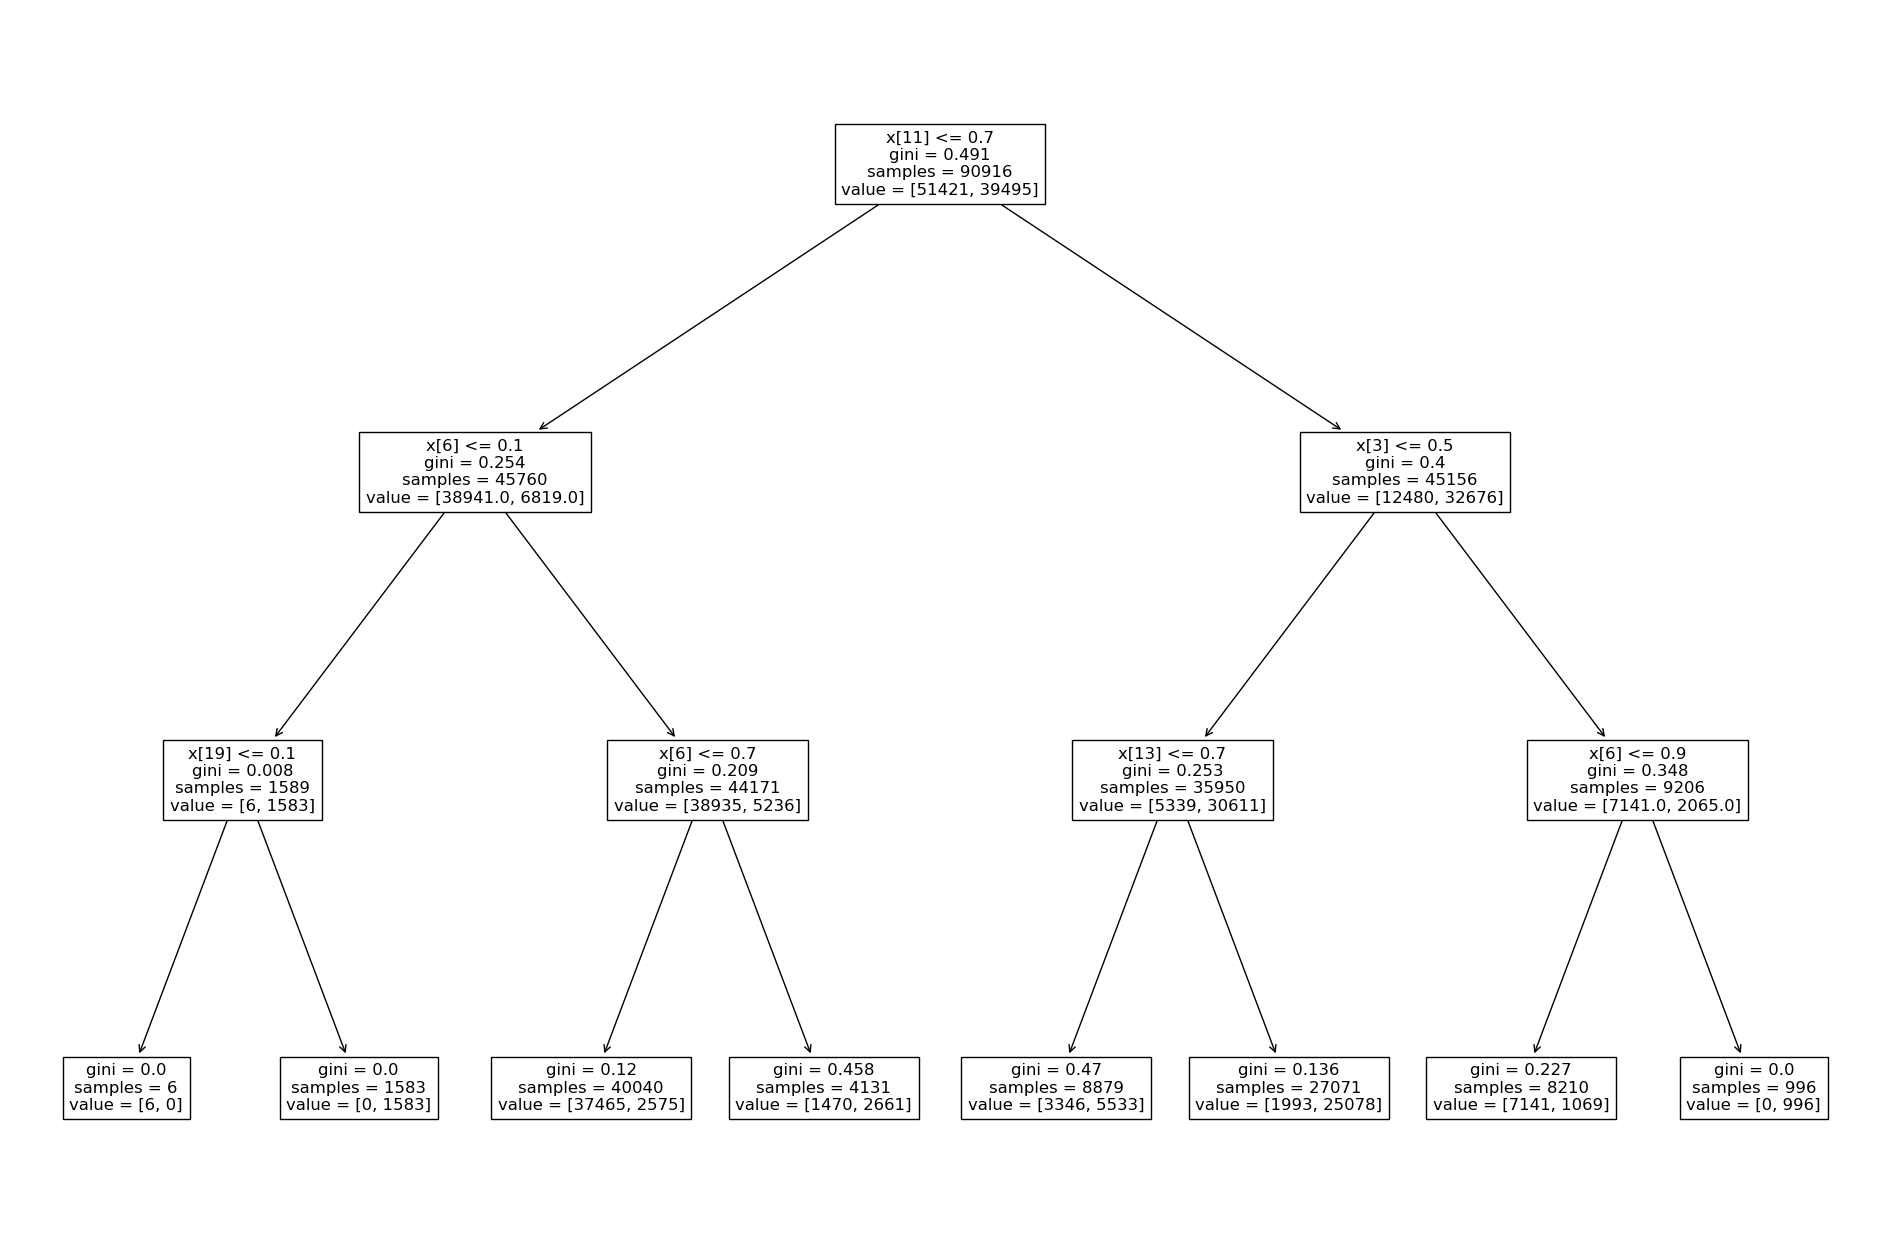

In [73]:
plt.figure(figsize=(24,16))
from sklearn import tree

tree.plot_tree(clf_gini.fit(X_train,y_train))
plt.show()

In [74]:

import pickle

dosyalar = {
    "Decision Tree": r"model_decision_trees_gini.pkl"
}

for name, path in dosyalar.items():
    loaded = pickle.load(open(path, "rb"))
    print(f"{name} — Scaler: {loaded['scaler'].n_features_in_} | Model: {loaded['model'].n_features_in_}")

Decision Tree — Scaler: 22 | Model: 22
